# Практическая работа № 1
## Самостоятельный анализ: UCI Bike Sharing Dataset

### 1. Постановка задачи

**Цель:** исследовать почасовой спрос на прокат велосипедов и его связь с сезоном, погодой, температурой и рабочими днями, а также проверить временную динамику и воспроизводимый экспорт.

**Источник:** Hadi Fanaee-T, *Bike Sharing Dataset*, UCI Machine Learning Repository, DOI: [10.24432/C5W894](https://doi.org/10.24432/C5W894). Лицензия на странице UCI — CC BY 4.0. Локальные сведения и оригинальный README сохранены в `data/SOURCE.md` и `data/UCI_Readme.txt`.

Данные агрегированы по часам за 2011-2012 годы для Capital Bikeshare (Вашингтон, США). Персональных записей нет: строки содержат суммарное число прокатов, календарные и погодные признаки.

### Окружение и проверка CSV

In [1]:
from pathlib import Path
import csv
import io
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

NOTEBOOK_DIR = Path.cwd()
DATA_PATH = NOTEBOOK_DIR / "data" / "bike_sharing_hour.csv"
OUT = NOTEBOOK_DIR / "output" / "own"
OUT.mkdir(parents=True, exist_ok=True)

raw_bytes = DATA_PATH.read_bytes()
encoding = "ascii" if all(byte < 128 for byte in raw_bytes[:100_000]) else "utf-8"
sample_text = raw_bytes[:10_000].decode(encoding)
delimiter = csv.Sniffer().sniff(sample_text).delimiter
print("Файл:", DATA_PATH.resolve())
print("Кодировка:", encoding)
print("Разделитель:", repr(delimiter))

raw_df = pd.read_csv(DATA_PATH, sep=delimiter, encoding=encoding)
print("Форма:", raw_df.shape)
display(raw_df.head())
assert raw_df.shape == (17379, 17)

Python: 3.12.2
pandas: 3.0.1
NumPy: 2.4.2
Matplotlib: 3.10.8
Файл: /Users/gankolcherin/myfolder/mirea-4/mirea-4-1/subjects/tiabd/1/submission/data/bike_sharing_hour.csv
Кодировка: ascii
Разделитель: ','
Форма: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Интерпретация.** Файл однозначно распознан как ASCII/UTF-8 CSV с запятой. Он содержит 17 379 почасовых записей и 17 исходных полей, поэтому превышает минимумы задания.

## 2. Паспорт данных

In [2]:
data_dictionary = pd.DataFrame([
    ("instant", "int", "Технический порядковый номер записи"),
    ("dteday", "date", "Календарная дата"),
    ("season", "category", "Сезон: 1 spring, 2 summer, 3 fall, 4 winter"),
    ("yr", "category", "Год: 0 = 2011, 1 = 2012"),
    ("mnth", "category", "Месяц 1-12"),
    ("hr", "category", "Час 0-23"),
    ("holiday", "binary", "Праздничный день"),
    ("weekday", "category", "День недели"),
    ("workingday", "binary", "Не выходной и не праздник"),
    ("weathersit", "category", "Категория погодной ситуации 1-4"),
    ("temp", "float", "Нормированная температура; исходная шкала делилась на 41"),
    ("atemp", "float", "Нормированная ощущаемая температура; шкала делилась на 50"),
    ("hum", "float", "Нормированная влажность; шкала делилась на 100"),
    ("windspeed", "float", "Нормированная скорость ветра; шкала делилась на 67"),
    ("casual", "int", "Число прокатов незарегистрированных пользователей"),
    ("registered", "int", "Число прокатов зарегистрированных пользователей"),
    ("cnt", "int", "Общее число прокатов: casual + registered"),
], columns=["Поле", "Смысловой тип", "Описание"])
display(data_dictionary)
print(raw_df.dtypes)

,Поле,Смысловой тип,Описание
0,instant,int,Технический порядковый номер записи
1,dteday,date,Календарная дата
2,season,category,"Сезон: 1 spring, 2 summer, 3 fall, 4 winter"
3,yr,category,"Год: 0 = 2011, 1 = 2012"
4,mnth,category,Месяц 1-12
5,hr,category,Час 0-23
6,holiday,binary,Праздничный день
7,weekday,category,День недели
8,workingday,binary,Не выходной и не праздник
9,weathersit,category,Категория погодной ситуации 1-4


instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [3]:
buf = io.StringIO()
raw_df.info(buf=buf, memory_usage="deep")
print(buf.getvalue())
display(raw_df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
instant,17379.0,NaN,NaN,NaN,8690.0,5017.0295,1.0,4345.5,8690.0,13034.5,17379.0
dteday,17379,731,2011-01-01,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,17379.0,NaN,NaN,NaN,2.50164,1.106918,1.0,2.0,3.0,3.0,4.0
yr,17379.0,NaN,NaN,NaN,0.502561,0.500008,0.0,0.0,1.0,1.0,1.0
mnth,17379.0,NaN,NaN,NaN,6.537775,3.438776,1.0,4.0,7.0,10.0,12.0
hr,17379.0,NaN,NaN,NaN,11.546752,6.914405,0.0,6.0,12.0,18.0,23.0
holiday,17379.0,NaN,NaN,NaN,0.02877,0.167165,0.0,0.0,0.0,0.0,1.0
weekday,17379.0,NaN,NaN,NaN,3.003683,2.005771,0.0,1.0,3.0,5.0,6.0
workingday,17379.0,NaN,NaN,NaN,0.682721,0.465431,0.0,0.0,1.0,1.0,1.0
weathersit,17379.0,NaN,NaN,NaN,1.425283,0.639357,1.0,1.0,1.0,2.0,4.0


**Интерпретация.** При первичном чтении дата является строкой, а календарные коды — целыми числами. Это технически корректно, но не отражает их смысл и будет исправлено. `instant` уникален и служит только номером строки.

## 3. Качество и предобработка

In [4]:
quality = pd.DataFrame({
    "missing": raw_df.isna().sum(),
    "unique": raw_df.nunique(dropna=False),
})
display(quality)
print("Полных дубликатов:", int(raw_df.duplicated().sum()))
print("instant уникален:", bool(raw_df["instant"].is_unique))
print("cnt = casual + registered:", bool(raw_df["cnt"].eq(raw_df["casual"] + raw_df["registered"]).all()))
print("temp, atemp, hum, windspeed находятся в [0, 1]:", bool(raw_df[["temp", "atemp", "hum", "windspeed"]].apply(lambda s: s.between(0, 1).all()).all()))

,missing,unique
instant,0,17379
dteday,0,731
season,0,4
yr,0,2
mnth,0,12
hr,0,24
holiday,0,2
weekday,0,7
workingday,0,2
weathersit,0,4


Полных дубликатов: 0
instant уникален: True
cnt = casual + registered: True
temp, atemp, hum, windspeed находятся в [0, 1]: True


**Интерпретация.** Ячеечных пропусков и полных дублей нет, контрольная сумма `cnt = casual + registered` выполняется для всех строк, а нормированные признаки лежат в ожидаемом диапазоне. Удалять наблюдения нет оснований; вместо этого уточняются типы и проверяется полнота временной сетки.

In [5]:
before = raw_df.memory_usage(deep=True).sum()
typed_df = raw_df.copy()
typed_df["dteday"] = pd.to_datetime(typed_df["dteday"], format="%Y-%m-%d", errors="raise")
for col in ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]:
    typed_df[col] = typed_df[col].astype("int8")
after = typed_df.memory_usage(deep=True).sum()

print(f"Память до: {before / 1024**2:.2f} MiB")
print(f"Память после типизации: {after / 1024**2:.2f} MiB")
print(f"Снижение: {(1 - after / before) * 100:.1f}%")

clean_df = typed_df.drop(columns="instant").copy()
season_labels = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
weather_labels = {
    1: "Clear/partly cloudy",
    2: "Mist/cloudy",
    3: "Light rain/snow",
    4: "Heavy rain/snow",
}
clean_df["season_name"] = clean_df["season"].map(season_labels).astype("category")
clean_df["weather_name"] = clean_df["weathersit"].map(weather_labels).astype("category")
print(clean_df.dtypes)

Память до: 2.42 MiB
Память после типизации: 1.33 MiB
Снижение: 45.2%
dteday          datetime64[us]
season                    int8
yr                        int8
mnth                      int8
hr                        int8
holiday                   int8
weekday                   int8
workingday                int8
weathersit                int8
temp                   float64
atemp                  float64
hum                    float64
windspeed              float64
casual                   int64
registered               int64
cnt                      int64
season_name           category
weather_name          category
dtype: object


**Обоснование.** Дата приведена к `datetime64[us]`, небольшие коды — к `int8`, а подписи сезона и погоды — к `category`. Это уменьшило память типизированных исходных полей на 45.2%. `instant` удалён из аналитической таблицы как технический уникальный номер, не несущий признака спроса.

### Вычисляемые признаки и временная полнота

In [6]:
clean_df["timestamp"] = clean_df["dteday"] + pd.to_timedelta(clean_df["hr"], unit="h")
clean_df["temp_c"] = (clean_df["temp"] * 41).round(2)
clean_df["feels_like_c"] = (clean_df["atemp"] * 50).round(2)
clean_df["humidity_pct"] = (clean_df["hum"] * 100).round(1)
clean_df["wind_speed_scaled"] = (clean_df["windspeed"] * 67).round(2)
clean_df["registered_share_pct"] = (clean_df["registered"] / clean_df["cnt"] * 100).round(2)

full_hours = pd.date_range(clean_df["timestamp"].min(), clean_df["timestamp"].max(), freq="h")
missing_hours = full_hours.difference(clean_df["timestamp"])
print("Период:", clean_df["timestamp"].min(), "-", clean_df["timestamp"].max())
print("Дубликатов timestamp:", int(clean_df["timestamp"].duplicated().sum()))
print("Отсутствующих часов внутри диапазона:", len(missing_hours))
display(clean_df[["timestamp", "temp", "temp_c", "registered_share_pct"]].head())

Период: 2011-01-01 00:00:00 - 2012-12-31 23:00:00
Дубликатов timestamp: 0
Отсутствующих часов внутри диапазона: 165


,timestamp,temp,temp_c,registered_share_pct
0,2011-01-01 00:00:00,0.24,9.84,81.25
1,2011-01-01 01:00:00,0.22,9.02,80.00
2,2011-01-01 02:00:00,0.22,9.02,84.38
3,2011-01-01 03:00:00,0.24,9.84,76.92
4,2011-01-01 04:00:00,0.24,9.84,100.00


**Интерпретация.** Формулы возвращают температуру в °C (`temp_c = 41 * temp`) и долю зарегистрированных прокатов (`100 * registered / cnt`). Временные метки уникальны, но внутри полного часового диапазона отсутствуют 165 часов: отсутствие пустых ячеек не означает непрерывность временного ряда.

### Составной фильтр через `loc`

In [7]:
morning_workday = clean_df.loc[
    (clean_df["workingday"] == 1)
    & (clean_df["weather_name"] == "Clear/partly cloudy")
    & (clean_df["temp_c"] >= 20)
    & (clean_df["hr"].between(7, 9)),
    ["timestamp", "season_name", "temp_c", "weather_name", "cnt"],
]
print("Строк в срезе:", len(morning_workday))
print("Среднее число прокатов:", round(morning_workday["cnt"].mean(), 2))
print("Медиана:", morning_workday["cnt"].median())
display(morning_workday.head())

Строк в срезе: 383
Среднее число прокатов: 408.47
Медиана: 370.0


,timestamp,season_name,temp_c,weather_name,cnt
2530,2011-04-20 08:00:00,Summer,25.42,Clear/partly cloudy,396
2531,2011-04-20 09:00:00,Summer,27.06,Clear/partly cloudy,197
2650,2011-04-25 08:00:00,Summer,22.96,Clear/partly cloudy,353
2651,2011-04-25 09:00:00,Summer,24.60,Clear/partly cloudy,174
2673,2011-04-26 07:00:00,Summer,23.78,Clear/partly cloudy,270


**Интерпретация.** Условиям рабочего утра 07:00-09:00, ясной/переменно облачной погоды и температуры не ниже 20 °C соответствуют 383 часа. Среднее число прокатов в них — около 408.47, медиана — 370; это описательный срез, а не доказательство влияния каждого условия.

## 4. EDA

### Группировки и агрегации

In [8]:
season_stats = (
    clean_df.groupby("season_name", observed=True)
    .agg(
        n_hours=("cnt", "size"),
        total_rentals=("cnt", "sum"),
        mean_per_hour=("cnt", "mean"),
        median_per_hour=("cnt", "median"),
        mean_temp_c=("temp_c", "mean"),
    )
    .sort_values("mean_per_hour", ascending=False)
)
display(season_stats.round(2))

weather_stats = (
    clean_df.groupby("weather_name", observed=True)
    .agg(n_hours=("cnt", "size"), total_rentals=("cnt", "sum"), mean_per_hour=("cnt", "mean"))
    .sort_values("mean_per_hour", ascending=False)
)
display(weather_stats.round(2))

,n_hours,total_rentals,mean_per_hour,median_per_hour,mean_temp_c
season_name,,,,,
Fall,4496,1061129,236.02,199.0,28.96
Summer,4409,918589,208.34,165.0,22.33
Winter,4232,841613,198.87,155.5,17.35
Spring,4242,471348,111.11,76.0,12.27


,n_hours,total_rentals,mean_per_hour
weather_name,,,
Clear/partly cloudy,11413,2338173,204.87
Mist/cloudy,4544,795952,175.17
Light rain/snow,1419,158331,111.58
Heavy rain/snow,3,223,74.33


**Интерпретация.** Наибольшее среднее число прокатов наблюдается осенью (`Fall`) — 236.02 в час, наименьшее весной (`Spring`) — 111.11. При ясной/переменно облачной погоде среднее равно 204.87, при лёгком дожде/снеге — 111.58. Категория тяжёлой погоды содержит только 3 часа, поэтому её среднее 74.33 статистически неустойчиво.

### Описательные статистики и корреляция

In [9]:
eda_cols = ["cnt", "temp_c", "humidity_pct", "wind_speed_scaled", "registered_share_pct"]
display(clean_df[eda_cols].describe().round(2).T)
display(clean_df[["cnt", "temp_c", "humidity_pct", "windspeed"]].corr().round(3))

,count,mean,std,min,25%,50%,75%,max
cnt,17379.0,189.46,181.39,1.00,40.00,142.00,281.00,977.0
temp_c,17379.0,20.38,7.89,0.82,13.94,20.50,27.06,41.0
humidity_pct,17379.0,62.72,19.29,0.00,48.00,63.00,78.00,100.0
wind_speed_scaled,17379.0,12.74,8.20,0.00,7.00,13.00,17.00,57.0
registered_share_pct,17379.0,82.79,13.66,0.00,74.63,85.31,93.65,100.0


,cnt,temp_c,humidity_pct,windspeed
cnt,1.000,0.405,-0.323,0.093
temp_c,0.405,1.000,-0.070,-0.023
humidity_pct,-0.323,-0.070,1.000,-0.290
windspeed,0.093,-0.023,-0.290,1.000


**Интерпретация.** Почасовой спрос асимметричен: среднее 189.46 выше медианы 142, максимум — 977. Корреляция спроса с температурой умеренно положительна (`r = 0.405`), с влажностью — умеренно отрицательна (`r = -0.323`), а со скоростью ветра близка к нулю (`r = 0.093`). Эти коэффициенты не доказывают причинность.

### Кандидаты на выбросы по IQR

In [10]:
q1 = clean_df["cnt"].quantile(0.25)
q3 = clean_df["cnt"].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
cnt_outliers = ~clean_df["cnt"].between(lower, upper)
print(f"Q1={q1:.1f}; Q3={q3:.1f}; IQR={iqr:.1f}")
print(f"Границы: [{lower:.1f}; {upper:.1f}]")
print(f"Кандидатов: {cnt_outliers.sum()} ({cnt_outliers.mean() * 100:.2f}%)")

Q1=40.0; Q3=281.0; IQR=241.0
Границы: [-321.5; 642.5]
Кандидатов: 505 (2.91%)


**Интерпретация.** Верхняя граница IQR равна 642.5 проката, выше неё лежат 505 часов (2.91%). Высокий спрос реалистичен для часов пик, поэтому кандидаты не удаляются автоматически.

### Визуализация 1. Категориальное сравнение

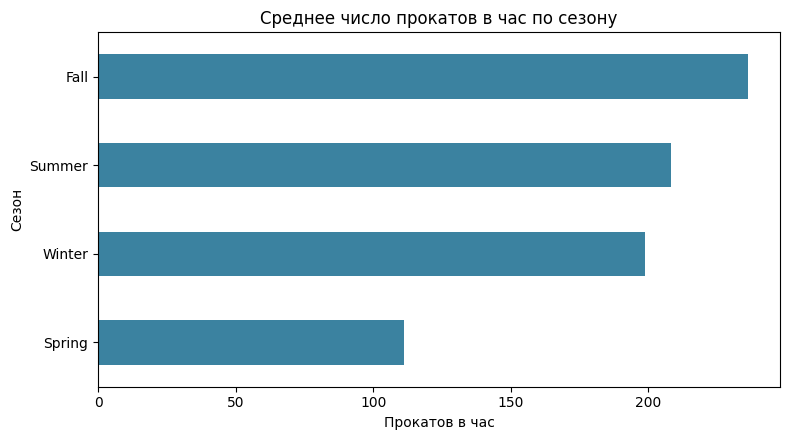

In [11]:
order = season_stats.sort_values("mean_per_hour").index
ax = season_stats.loc[order, "mean_per_hour"].plot(kind="barh", figsize=(8, 4.5), color="#3b82a0")
ax.set_title("Среднее число прокатов в час по сезону")
ax.set_xlabel("Прокатов в час")
ax.set_ylabel("Сезон")
plt.tight_layout()
plt.show()

**Интерпретация.** Средний почасовой спрос выше всего для `Fall` и ниже всего для `Spring`; сезонные различия могут одновременно отражать погоду, тренд между годами и структуру календаря.

### Визуализация 2. Распределение спроса

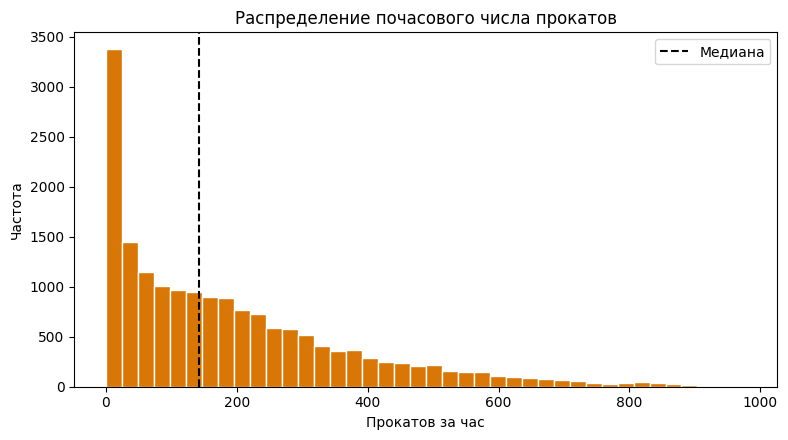

In [12]:
plt.figure(figsize=(8, 4.5))
plt.hist(clean_df["cnt"], bins=40, edgecolor="white", color="#d97706")
plt.axvline(clean_df["cnt"].median(), color="black", linestyle="--", label="Медиана")
plt.title("Распределение почасового числа прокатов")
plt.xlabel("Прокатов за час")
plt.ylabel("Частота")
plt.legend()
plt.tight_layout()
plt.show()

**Интерпретация.** Распределение имеет длинный правый хвост: большинство часов значительно ниже максимума 977, а среднее превышает медиану.

### Визуализация 3. Температура и спрос

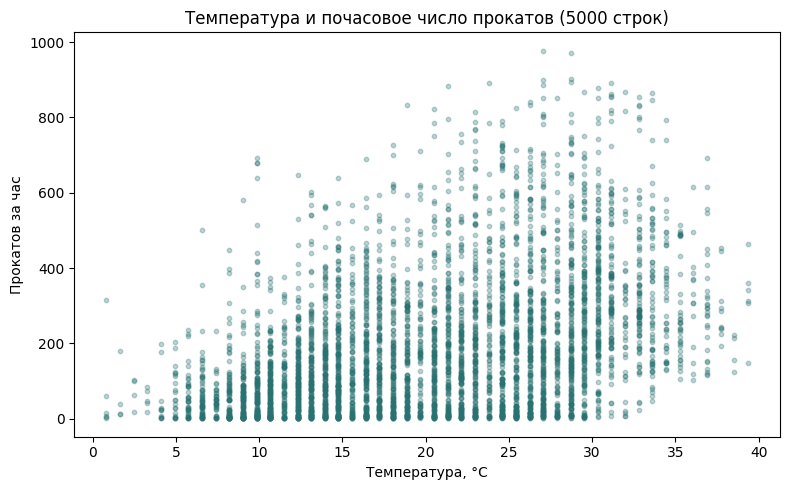

In [13]:
sample = clean_df.sample(n=5000, random_state=42)
plt.figure(figsize=(8, 5))
plt.scatter(sample["temp_c"], sample["cnt"], s=10, alpha=0.3, color="#287271")
plt.title("Температура и почасовое число прокатов (5000 строк)")
plt.xlabel("Температура, °C")
plt.ylabel("Прокатов за час")
plt.tight_layout()
plt.show()

**Интерпретация.** При более высокой температуре верхняя граница спроса в среднем растёт, но большой вертикальный разброс показывает влияние часа, сезона, года и других факторов.

### Визуализация 4. Временной ряд

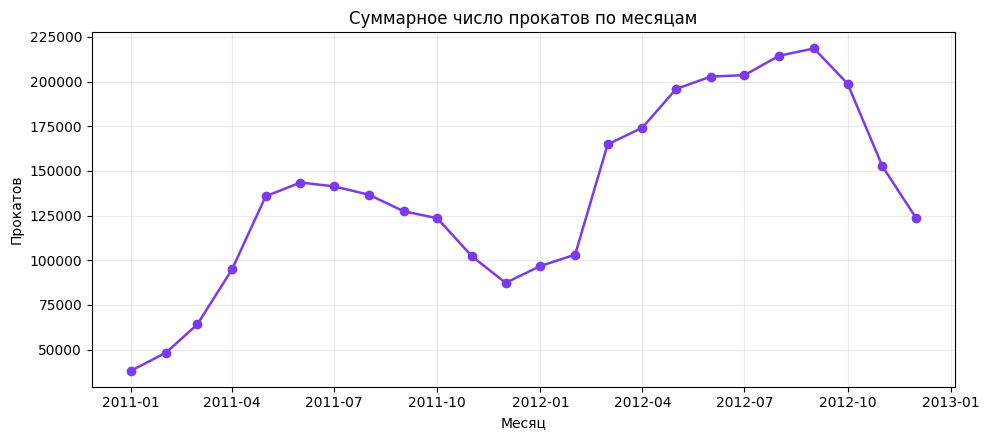

,rentals
dteday,
2011-01-01,38189
2011-02-01,48215
2011-03-01,64045
2011-04-01,94870
2011-05-01,135821


In [14]:
monthly = clean_df.resample("MS", on="dteday")["cnt"].sum()
plt.figure(figsize=(10, 4.5))
plt.plot(monthly.index, monthly.values, marker="o", linewidth=1.8, color="#7c3aed")
plt.title("Суммарное число прокатов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Прокатов")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
display(monthly.rename("rentals").to_frame().head())

**Интерпретация.** В 2012 году месячные суммы в целом выше, чем в 2011-м, с сезонными подъёмами в тёплые месяцы. Максимум приходится на сентябрь 2012 года (218 573 проката), минимум — на январь 2011 года (38 189). Суммы рассчитаны по имеющимся строкам; 165 часов отсутствуют во временной сетке.

## 5. Интерпретация

Анализ показывает совместное действие календаря, погоды и общего временного тренда. Сезонные и погодные средние нельзя трактовать изолированно: например, рост популярности сервиса между 2011 и 2012 годами способен повышать средние поздних периодов. Поэтому результаты описывают наблюдения и формируют гипотезы, но не оценивают причинный эффект температуры или погоды.

## 6. Экспорт и повторное чтение

In [15]:
own_csv = OUT / "bike_sharing_clean.csv"
own_json = OUT / "bike_sharing_clean.json"
own_parquet = OUT / "bike_sharing_clean.parquet"

clean_df.to_csv(own_csv, index=False, encoding="utf-8")
clean_df.to_json(own_json, orient="records", lines=True, force_ascii=False, date_format="iso")
clean_df.to_parquet(own_parquet, index=False, engine="pyarrow", compression="snappy")

sizes = pd.DataFrame({
    "format": ["CSV", "JSON Lines", "Parquet"],
    "size_MiB": [p.stat().st_size / 1024**2 for p in [own_csv, own_json, own_parquet]],
}).set_index("format")
display(sizes.round(3))

csv_back = pd.read_csv(own_csv)
json_back = pd.read_json(own_json, lines=True)
parquet_back = pd.read_parquet(own_parquet)
round_trip = pd.DataFrame({
    "shape": [csv_back.shape, json_back.shape, parquet_back.shape],
    "dteday_dtype": [str(csv_back["dteday"].dtype), str(json_back["dteday"].dtype), str(parquet_back["dteday"].dtype)],
    "season_name_dtype": [str(csv_back["season_name"].dtype), str(json_back["season_name"].dtype), str(parquet_back["season_name"].dtype)],
}, index=["CSV", "JSON Lines", "Parquet"])
display(round_trip)

assert csv_back.shape == clean_df.shape
assert json_back.shape == clean_df.shape
assert parquet_back.shape == clean_df.shape
assert pd.api.types.is_datetime64_any_dtype(parquet_back["dteday"])
assert isinstance(parquet_back["season_name"].dtype, pd.CategoricalDtype)

,size_MiB
format,
CSV,2.179
JSON Lines,7.035
Parquet,0.385


,shape,dteday_dtype,season_name_dtype
CSV,"(17379, 24)",str,str
JSON Lines,"(17379, 24)",str,str
Parquet,"(17379, 24)",datetime64[us],category


**Интерпретация.** Все три формата прошли round-trip и сохранили форму таблицы. CSV и JSON требуют повторного распознавания дат и категорий, а Parquet сохранил `datetime` и `category`, поэтому удобнее для следующего аналитического этапа.

## 7. Итог

### Выводы

1. Набор содержит 17 379 почасовых наблюдений, 17 исходных полей, не имеет пустых ячеек и полных дубликатов; `cnt` всегда равен `casual + registered`.
2. После приведения даты и малых кодов к подходящим типам память исходных полей сократилась на 45.2%.
3. Средний почасовой спрос равен 189.46, медиана — 142, максимум — 977; распределение имеет правый хвост.
4. Наибольший средний спрос наблюдается в сезоне `Fall` (236.02 проката/час), наименьший — в `Spring` (111.11).
5. При ясной/переменно облачной погоде средний спрос (204.87) выше, чем при лёгком дожде/снеге (111.58), но причинность из групповых средних не следует.
6. Спрос умеренно положительно коррелирует с температурой (`r = 0.405`) и отрицательно — с влажностью (`r = -0.323`).
7. IQR помечает 505 часов (2.91%) с высоким спросом; они сохранены как возможные реальные часы пик.
8. Месячный максимум — сентябрь 2012 года (218 573 проката), минимум — январь 2011 года (38 189); виден общий рост и сезонность.

### Ограничения

1. Данные относятся к одной системе и двум годам; результаты нельзя автоматически переносить на другие города и периоды.
2. Внутри часового диапазона отсутствуют 165 временных меток, хотя пропусков в самих строках нет; месячные суммы рассчитаны по доступным наблюдениям.
3. В данных нет станций, маршрутов и индивидуальной длительности поездок, поэтому пространственный и пользовательский анализ невозможен.
4. Исследование наблюдательное: корреляции и групповые различия не доказывают причинный эффект погоды или календаря.
5. Для категории тяжёлой погоды есть только 3 часа, поэтому её среднее ненадёжно.